In [2]:
import torch
import requests
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np
from transformers import ViTImageProcessor, ViTForImageClassification

# 1. Load the Processor and Model (Moving to GPU to keep it fast)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

processor = ViTImageProcessor.from_pretrained('google/vit-base-patch16-224')
# CRITICAL: We must request output_attentions=True as per the assignment
model = ViTForImageClassification.from_pretrained(
    'google/vit-base-patch16-224', 
    output_attentions=True
).to(device)
model.eval()

# 2. Fetch a standard test image 
url = 'https://images.unsplash.com/photo-1537151608828-ea2b11777ee8?q=80&w=400&auto=format&fit=crop'
image = Image.open(requests.get(url, stream=True).raw).convert("RGB")

# 3. Preprocess the image (resizes to 224x224 and normalizes)
inputs = processor(images=image, return_tensors="pt").to(device)

# 4. Forward Pass (Subtask 1)
with torch.no_grad():
    outputs = model(**inputs)

# 5. Extract Prediction
logits = outputs.logits
predicted_class_idx = logits.argmax(-1).item()
predicted_label = model.config.id2label[predicted_class_idx]
print(f"Top-1 Prediction: {predicted_label}")

Using device: cuda


Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

Top-1 Prediction: Pembroke, Pembroke Welsh corgi


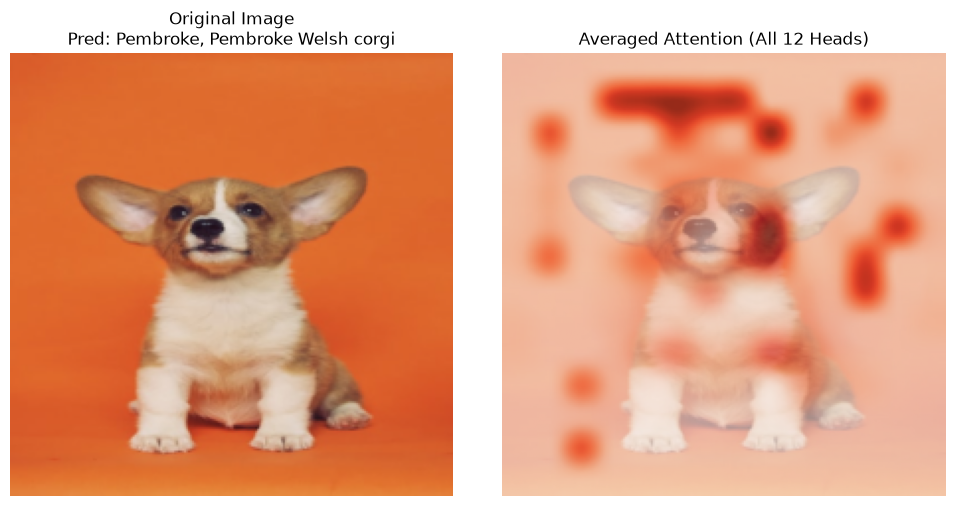

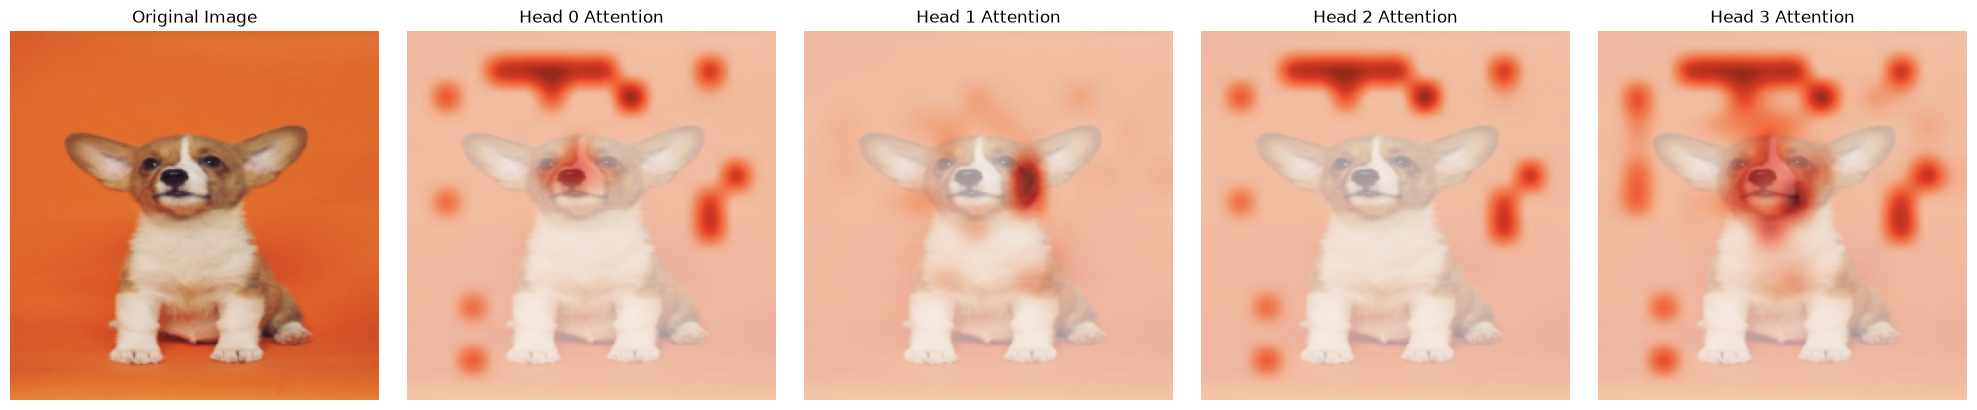

In [4]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

# 1. Correct Image Un-normalization for ViT
original_resized = inputs['pixel_values'].squeeze().cpu().numpy()
original_resized = np.transpose(original_resized, (1, 2, 0))
original_resized = 0.5 * original_resized + 0.5 
original_resized = np.clip(original_resized, 0, 1)

# Extract final layer attention. Shape: (1, 12, 197, 197)
final_layer_attn = outputs.attentions[-1]

# ==========================================
# FIGURE A: The Averaged Attention Map
# ==========================================
# Average across all 12 heads
mean_attn = final_layer_attn.mean(dim=1).squeeze()
avg_cls_attn = mean_attn[0, 1:].cpu().numpy().reshape(14, 14)

# Normalize and upsample
avg_cls_attn = (avg_cls_attn - avg_cls_attn.min()) / (avg_cls_attn.max() - avg_cls_attn.min())
avg_attn_image = Image.fromarray(np.uint8(avg_cls_attn * 255)).resize((224, 224), resample=Image.BICUBIC)
avg_heatmap = np.array(avg_attn_image) / 255.0

fig_avg, axes_avg = plt.subplots(1, 2, figsize=(10, 5))
axes_avg[0].imshow(original_resized)
axes_avg[0].set_title(f"Original Image\nPred: {predicted_label}")
axes_avg[0].axis('off')

axes_avg[1].imshow(original_resized)
axes_avg[1].imshow(avg_heatmap, cmap='Reds', alpha=0.6)
axes_avg[1].set_title("Averaged Attention (All 12 Heads)")
axes_avg[1].axis('off')

plt.tight_layout()
plt.savefig('../report/figures/task2_averaged_map.png', dpi=300)
plt.show()

# ==========================================
# FIGURE B: Proving Head Specialization
# ==========================================
fig_heads, axes_heads = plt.subplots(1, 5, figsize=(20, 4))
axes_heads[0].imshow(original_resized)
axes_heads[0].set_title("Original Image")
axes_heads[0].axis('off')

# Plot the first 4 heads independently
for head_idx in range(4):
    head_attn = final_layer_attn[0, head_idx, 0, 1:].reshape(14, 14).cpu().numpy()
    head_attn = (head_attn - head_attn.min()) / (head_attn.max() - head_attn.min())
    
    attn_image = Image.fromarray(np.uint8(head_attn * 255)).resize((224, 224), resample=Image.BICUBIC)
    heatmap = np.array(attn_image) / 255.0
    
    axes_heads[head_idx+1].imshow(original_resized)
    axes_heads[head_idx+1].imshow(heatmap, cmap='Reds', alpha=0.6)
    axes_heads[head_idx+1].set_title(f"Head {head_idx} Attention")
    axes_heads[head_idx+1].axis('off')

plt.tight_layout()
plt.savefig('../report/figures/task2_individual_heads.png', dpi=300)
plt.show()

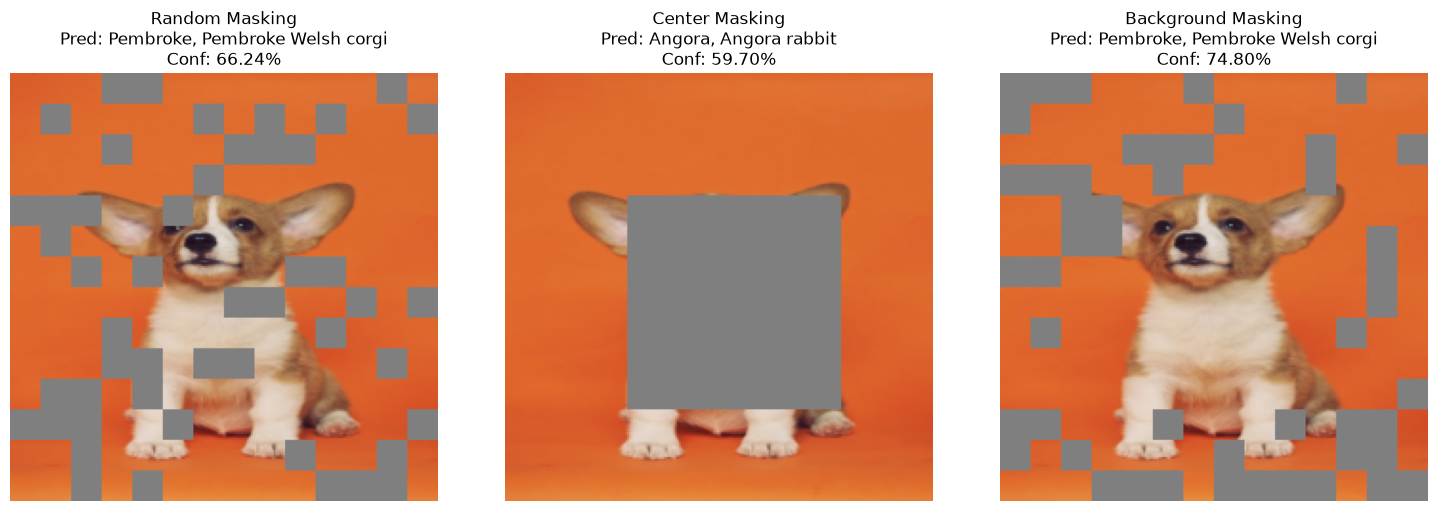

In [5]:
import copy
import random

# Helper function to mask patches in the image
def apply_mask(image_tensor, mask_indices, patch_size=16):
    # image_tensor shape: (1, 3, 224, 224)
    masked_img = image_tensor.clone()
    
    # We replace masked patches with 0 (which corresponds to the mean pixel value 
    # after standard normalization, keeping it neutral so it doesn't skew the model)
    for idx in mask_indices:
        row = idx // 14
        col = idx % 14
        y_start, y_end = row * patch_size, (row + 1) * patch_size
        x_start, x_end = col * patch_size, (col + 1) * patch_size
        masked_img[0, :, y_start:y_end, x_start:x_end] = 0.0
        
    return masked_img

# We have 14x14 = 196 patches. We will mask 25% (49 patches).
num_patches = 196
mask_count = 49

# 1. Random Masking
random_indices = random.sample(range(num_patches), mask_count)
random_masked_input = apply_mask(inputs['pixel_values'], random_indices)

# 2. Center Masking (Masking the middle 7x7 grid)
center_indices = []
for r in range(4, 11):
    for c in range(4, 11):
        center_indices.append(r * 14 + c)
        
center_masked_input = apply_mask(inputs['pixel_values'], center_indices)

# 3. Background Masking (Masking the outer edges)
all_indices = set(range(num_patches))
background_indices = list(all_indices - set(center_indices))
# Sample 49 from the background to keep the missing data percentage equal
background_indices = random.sample(background_indices, mask_count) 

bg_masked_input = apply_mask(inputs['pixel_values'], background_indices)

# --- Run Inference on Masked Images ---
model.eval()
with torch.no_grad():
    out_random = model(pixel_values=random_masked_input)
    out_center = model(pixel_values=center_masked_input)
    out_bg = model(pixel_values=bg_masked_input)

# Get predictions and confidences
def get_pred(out):
    probs = torch.nn.functional.softmax(out.logits, dim=-1)
    conf, idx = torch.max(probs, dim=-1)
    return model.config.id2label[idx.item()], conf.item()

pred_random, conf_random = get_pred(out_random)
pred_center, conf_center = get_pred(out_center)
pred_bg, conf_bg = get_pred(out_bg)

# --- Plot the Results ---
def unnormalize_for_plot(tensor):
    img = tensor.squeeze().cpu().numpy()
    img = np.transpose(img, (1, 2, 0))
    img = 0.5 * img + 0.5 
    return np.clip(img, 0, 1)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(unnormalize_for_plot(random_masked_input))
axes[0].set_title(f"Random Masking\nPred: {pred_random}\nConf: {conf_random:.2%}")
axes[0].axis('off')

axes[1].imshow(unnormalize_for_plot(center_masked_input))
axes[1].set_title(f"Center Masking\nPred: {pred_center}\nConf: {conf_center:.2%}")
axes[1].axis('off')

axes[2].imshow(unnormalize_for_plot(bg_masked_input))
axes[2].set_title(f"Background Masking\nPred: {pred_bg}\nConf: {conf_bg:.2%}")
axes[2].axis('off')

plt.tight_layout()
plt.savefig('../report/figures/task2_patch_masking.png', dpi=300)
plt.show()

Files already downloaded and verified
Files already downloaded and verified
Extracting training features...


Extracting Features: 100%|██████████| 157/157 [01:40<00:00,  1.56it/s]


Extracting testing features...


Extracting Features: 100%|██████████| 32/32 [00:21<00:00,  1.47it/s]



--- Training Linear Probes ---
CLS Token Probe Test Accuracy: 95.95%
Mean-Pooled Probe Test Accuracy: 97.00%


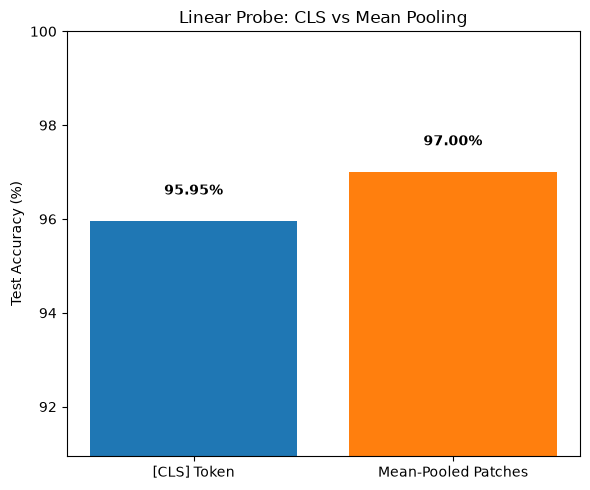

In [7]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Subset
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

# 1. Prepare CIFAR-10 Dataset Subset (10k train, 2k test for speed)
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    # Standard ViT normalization
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5]) 
])

# Download/load dataset
train_dataset = datasets.CIFAR10(root='../data', train=True, download=True, transform=transform)
test_dataset = datasets.CIFAR10(root='../data', train=False, download=True, transform=transform)
# Subset the data
train_subset = Subset(train_dataset, range(10000))
test_subset = Subset(test_dataset, range(2000))

train_loader = DataLoader(train_subset, batch_size=64, shuffle=True, num_workers=2)
test_loader = DataLoader(test_subset, batch_size=64, shuffle=False, num_workers=2)

# 2. Feature Extraction Function
def extract_features(loader):
    cls_features, mean_features, labels_list = [], [], []
    
    with torch.no_grad():
        for imgs, lbls in tqdm(loader, desc="Extracting Features"):
            imgs = imgs.to(device)
            # Ask the model to return hidden states
            outputs = model(pixel_values=imgs, output_hidden_states=True)
            
            # Get the final layer's hidden states. Shape: (batch_size, 197, 768)
            last_hidden = outputs.hidden_states[-1] 
            
            # CLS token is at index 0
            cls_feat = last_hidden[:, 0, :]
            
            # Mean pool the 196 patch tokens (index 1 to 196)
            mean_feat = last_hidden[:, 1:, :].mean(dim=1)
            
            cls_features.append(cls_feat.cpu())
            mean_features.append(mean_feat.cpu())
            labels_list.append(lbls)
            
    return torch.cat(cls_features), torch.cat(mean_features), torch.cat(labels_list)

print("Extracting training features...")
train_cls, train_mean, train_labels = extract_features(train_loader)
print("Extracting testing features...")
test_cls, test_mean, test_labels = extract_features(test_loader)

# 3. Train Linear Probes
class LinearProbe(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc = nn.Linear(768, 10) # 768 is ViT-Base hidden size, 10 CIFAR classes
        
    def forward(self, x):
        return self.fc(x)

def train_probe(train_x, train_y, test_x, test_y, name, epochs=20):
    probe = LinearProbe().to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(probe.parameters(), lr=0.001)
    
    train_ds = torch.utils.data.TensorDataset(train_x.to(device), train_y.to(device))
    train_dl = DataLoader(train_ds, batch_size=128, shuffle=True)
    
    for epoch in range(epochs):
        probe.train()
        for x_batch, y_batch in train_dl:
            optimizer.zero_grad()
            loss = criterion(probe(x_batch), y_batch)
            loss.backward()
            optimizer.step()
            
    # Evaluate
    probe.eval()
    with torch.no_grad():
        preds = probe(test_x.to(device)).argmax(dim=1)
        acc = (preds == test_y.to(device)).float().mean().item()
        
    print(f"{name} Probe Test Accuracy: {acc*100:.2f}%")
    return acc

print("\n--- Training Linear Probes ---")
cls_acc = train_probe(train_cls, train_labels, test_cls, test_labels, "CLS Token")
mean_acc = train_probe(train_mean, train_labels, test_mean, test_labels, "Mean-Pooled")

# 4. Plot Comparison
labels = ['[CLS] Token', 'Mean-Pooled Patches']
accuracies = [cls_acc * 100, mean_acc * 100]

plt.figure(figsize=(6, 5))
bars = plt.bar(labels, accuracies, color=['#1f77b4', '#ff7f0e'])
plt.ylim(min(accuracies) - 5, 100)
plt.ylabel('Test Accuracy (%)')
plt.title('Linear Probe: CLS vs Mean Pooling')

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.5, f'{yval:.2f}%', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.savefig('../report/figures/task2_pooling_comparison.png', dpi=300)
plt.show() 